In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================================================
# 🧠 PM2.5 Classification (5 Classes) using KNN + Borderline-SMOTE
# =========================================================

# === Block 1: Import Libraries ===
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.preprocessing import label_binarize
from tqdm import tqdm


In [4]:
# === Block 2: Optimize Resource Usage ===
import os
os.environ['OMP_NUM_THREADS'] = str(os.cpu_count())  # ใช้จำนวน core CPU เต็มที่
print(f"💻 Using CPU Threads: {os.cpu_count()}")


💻 Using CPU Threads: 2


In [5]:
# === Block 3: Load Dataset ===
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)
print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")


Train shape: (329623, 13), Test shape: (82406, 13)


In [6]:
# === Block 4: Separate Features and Target ===
TARGET = 'PM2.5_level'
X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]
X_test  = df_test.drop(columns=[TARGET])
y_test  = df_test[TARGET]


In [7]:
# === Block 5: Apply Borderline-SMOTE (Train only) ===
print("Before SMOTE:")
print(y_train.value_counts())

bsmote = BorderlineSMOTE(kind='borderline-1', random_state=42)
X_resampled, y_resampled = bsmote.fit_resample(X_train, y_train)

print("\nAfter Borderline-SMOTE:")
print(pd.Series(y_resampled).value_counts())


Before SMOTE:
PM2.5_level
5    128801
4     73062
1     64314
2     33504
3     29942
Name: count, dtype: int64

After Borderline-SMOTE:
PM2.5_level
5    128801
3    128801
2    128801
4    128801
1    128801
Name: count, dtype: int64


In [8]:
# === Block 6: 10-Fold Cross Validation ===
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_scores, prec_scores, rec_scores, f1_scores, auc_scores = [], [], [], [], []
knn = KNeighborsClassifier(n_jobs=-1)

for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_resampled, y_resampled), total=10), 1):
    X_tr, X_val = X_resampled.iloc[train_idx], X_resampled.iloc[val_idx]
    y_tr, y_val = y_resampled.iloc[train_idx], y_resampled.iloc[val_idx]

    knn.fit(X_tr, y_tr)
    y_pred = knn.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='macro')

    y_val_bin = label_binarize(y_val, classes=sorted(y_resampled.unique()))
    y_pred_bin = label_binarize(y_pred, classes=sorted(y_resampled.unique()))
    auc_val = roc_auc_score(y_val_bin, y_pred_bin, average='macro')

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc_val)

    print(f"Fold {fold}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}, AUC={auc_val:.3f}")


 10%|█         | 1/10 [00:23<03:31, 23.50s/it]

Fold 1: Accuracy=0.865, Precision=0.868, Recall=0.865, F1=0.865, AUC=0.916


 20%|██        | 2/10 [00:48<03:14, 24.26s/it]

Fold 2: Accuracy=0.866, Precision=0.870, Recall=0.866, F1=0.867, AUC=0.917


 30%|███       | 3/10 [01:14<02:55, 25.05s/it]

...

Fold 8: Accuracy=0.863, Precision=0.866, Recall=0.863, F1=0.863, AUC=0.914


 90%|█████████ | 9/10 [03:44<00:24, 24.93s/it]

Fold 9: Accuracy=0.867, Precision=0.870, Recall=0.867, F1=0.867, AUC=0.917


100%|██████████| 10/10 [04:09<00:00, 24.95s/it]

Fold 10: Accuracy=0.863, Precision=0.867, Recall=0.863, F1=0.863, AUC=0.914


In [9]:
# ==========================================
# === Block 7: Display CV Summary + Mean/SD
# ==========================================
cv_results = pd.DataFrame({
    'Fold': list(range(1, 11)),
    'Accuracy': acc_scores,
    'Precision': prec_scores,
    'Recall': rec_scores,
    'F1': f1_scores,
    'AUC_ROC': auc_scores
})

print("\n=== 10-Fold Cross Validation Results ===")
print(cv_results)

# --- Avg Cross-validation Metrics (Mean ± SD) ---
acc_mean, acc_sd = np.mean(acc_scores), np.std(acc_scores)
prec_mean, prec_sd = np.mean(prec_scores), np.std(prec_scores)
rec_mean, rec_sd = np.mean(rec_scores), np.std(rec_scores)
f1_mean, f1_sd = np.mean(f1_scores), np.std(f1_scores)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

print("\n📊 Cross-validation (10 folds) Metrics (Mean ± SD):")
print(f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall   : {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1-score : {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC-ROC  : {auc_mean:.3f} ± {auc_sd:.3f}")

# ==========================================================
# 🔹 Evaluate on Test Set (Refit on full resampled train)
# ==========================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# 1) Refit model บน train (หลัง Borderline-SMOTE)
knn.fit(X_resampled, y_resampled)

# 2) Predict on test set
y_pred_test = knn.predict(X_test)
y_pred_proba_test = knn.predict_proba(X_test)

# 3) คำนวณ metrics พื้นฐาน
test_accuracy  = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_recall    = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1        = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

# 4) คำนวณ AUC (ใช้ classes จากโมเดลเพื่อให้ตรงกับ predict_proba)
classes = knn.classes_
y_test_bin = label_binarize(y_test, classes=classes)
test_auc = roc_auc_score(y_test_bin, y_pred_proba_test, average='macro', multi_class='ovo')

# 5) แสดงผล
print("\n📈 Test Set Metrics:")
print(f"Accuracy: {test_accuracy:.3f}, Precision: {test_precision:.3f}, "
      f"Recall: {test_recall:.3f}, F1: {test_f1:.3f}, AUC: {test_auc:.3f}")

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test,
                            target_names=['Good', 'Moderate',
                                          'Unhealthy for Sensitive',
                                          'Unhealthy', 'Very Unhealthy'],
                            zero_division=0))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))


=== 10-Fold Cross Validation Results ===
   Fold  Accuracy  Precision    Recall        F1   AUC_ROC
0     1  0.865235   0.868437  0.865236  0.865362  0.915772
1     2  0.866477   0.869525  0.866476  0.866614  0.916548
2     3  0.864288   0.867540  0.864287  0.864445  0.915180
3     4  0.864676   0.867711  0.864677  0.864796  0.915423
4     5  0.866384   0.869478  0.866384  0.866553  0.916490
5     6  0.866661   0.869845  0.866661  0.866847  0.916663
6     7  0.866398   0.869366  0.866398  0.866491  0.916498
7     8  0.863090   0.866456  0.863090  0.863274  0.914431
8     9  0.866832   0.870219  0.866832  0.866975  0.916770
9    10  0.863183   0.866547  0.863183  0.863373  0.914490

📊 Cross-validation (10 folds) Metrics (Mean ± SD):
Accuracy : 0.865 ± 0.001
Precision: 0.869 ± 0.001
Recall   : 0.865 ± 0.001
F1-score : 0.865 ± 0.001
AUC-ROC  : 0.916 ± 0.001

📈 Test Set Metrics:
Accuracy: 0.700, Precision: 0.727, Recall: 0.700, F1: 0.711, AUC: 0.851

Classification Report:
               

In [12]:
# (Optional) Save summary to CSV
cv_summary = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])
base_path = '/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/MeanSD/'
cv_summary.to_csv(base_path + "KNN_BDL_mean_sd.csv", index=False)
print(f"💾 Mean + SD summary saved to {base_path}KNN_BDL_mean_sd.csv")


💾 Mean + SD summary saved to /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/MeanSDKNN_BDL_mean_sd.csv


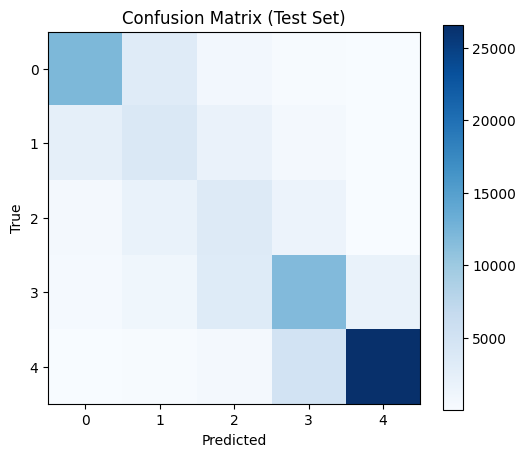

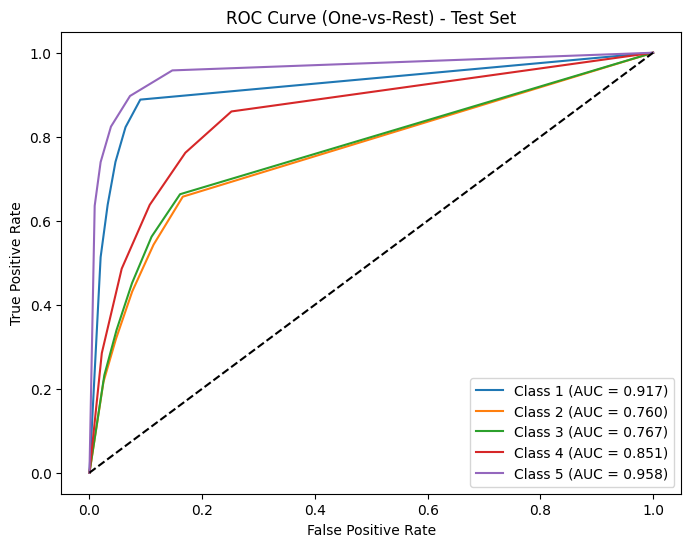

In [13]:
# === Block 9: Confusion Matrix and ROC Curve ===
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# 1) Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.show()

# 2) ROC Curve (One-vs-Rest) — ใช้ probability จาก predict_proba
classes = knn.classes_                 # ลำดับคลาสต้องตรงกับคอลัมน์ใน predict_proba
n_classes = len(classes)

# binarize y_test ให้ตรงกับลำดับ classes ของโมเดล
y_test_bin = label_binarize(y_test, classes=classes)

# ใช้ probability score แทน one-hot ของ prediction
y_pred_proba_test = knn.predict_proba(X_test)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - Test Set')
plt.legend()
plt.show()

In [ ]:
# === Block 10: Save Model, AUC CSV, and ROC Points (with Macro ROC Data) ===
from google.colab import drive
drive.mount('/content/drive')

# ระบุ path ให้เซฟในโฟลเดอร์เดียวกับไฟล์ปัจจุบัน (Colab)
base_path = '/content/drive/MyDrive/Senior_Project/'  # 🔧 เปลี่ยน path ได้ตามต้องการ

# --- Save Model ---
joblib.dump(knn, base_path + 'knn_borderline.pkl')
print(f"💾 Model saved as {base_path}knn_borderline.pkl")

# --- Save AUC per Fold + Test ---
output_auc = pd.DataFrame({
    'Fold': list(range(1, 11)) + ['Test Set'],
    'AUC_ROC': auc_scores + [test_auc]
})
output_auc.to_csv(base_path + 'knn_borderline_scores.csv', index=False)
print(f"💾 AUC results saved as {base_path}knn_borderline_scores.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
💾 Model saved as /content/drive/MyDrive/Senior_Project/knn_borderline.pkl
💾 AUC results saved as /content/drive/MyDrive/Senior_Project/knn_borderline_scores.csv


In [ ]:
# === ROC (OvR) ที่ถูกต้องและสอดคล้องกับโมเดล ===
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
import os

# 1) ใช้ลำดับคลาสจากโมเดล
classes = knn.classes_
n_classes = len(classes)

# 2) แปลง y_test เป็น one-hot ด้วย classes เดียวกับโมเดล
y_test_bin = label_binarize(y_test, classes=classes)

# 3) ใช้ "scores" เป็นความน่าจะเป็น ไม่ใช่ one-hot ของ y_pred
y_pred_proba_test = knn.predict_proba(X_test)

# 4) คำนวณ ROC ของแต่ละคลาส (one-vs-rest)
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# (ถ้าต้องการ macro-avg ROC เพิ่มเติม)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

In [ ]:
# === Save FPR and TPR for each class ===
roc_points = []
for i in range(n_classes):
    for fp, tp in zip(fpr[i], tpr[i]):
        roc_points.append({'Class': i, 'FPR': fp, 'TPR': tp})

roc_df = pd.DataFrame(roc_points)
roc_df.to_csv(base_path + 'knn_borderline_roc_points.csv', index=False)
print(f"💾 ROC points saved as {base_path}knn_borderline_roc_points.csv")

💾 ROC points saved as /content/drive/MyDrive/Senior_Project/knn_borderline_roc_points.csv
